In [4]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./output_28/"
for file in os.listdir(DIR)[:1]:
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

PKLs = []


for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [5]:
PKLs[0]

{'res': (None,
  None,
  None,
  Array([[[0.        , 0.5904167 ],
          [0.        , 1.005     ],
          [0.        , 0.75625   ],
          [0.        , 0.67333335],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ],
          [0.        , 0.5075    ]]], dtype=float32),
  None,
  Array([[[3.67914049e-06, 3.57737532e-03, 2.34262832e-02, ...,
           7.79350102e-02, 7.41969720e-02, 7.08503872e-02],
          [4.76430660e-06, 3.51369078e-03, 2.23674681e-02, ...,
           3.61378968e-01, 3.64918828e-01, 3.68034691e-01],
          [6.38545589e-06, 4.23019985e-03, 2.63010059e-02, ...,
           1.93970874e-01, 1.89427882e-01, 1.84844702e-01],
          ...,
          [6.42948589e-06, 6.09249854e-03, 3.66673805e-02, ...,
           1.09743394e-01, 1.09313592e-01, 1.08921088e-01],
          [7.11090297e-06, 6.1583165

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_3D(x, y, arr):
    # Assume arr is your n x n array
    X, Y = np.meshgrid(x, y)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    ax.plot_surface(X, Y, arr, cmap='viridis')  # you can change the colormap
    ax.set_xlabel(r'$\rho$ axis')
    ax.set_ylabel(r'$\tau$ axis')
    ax.set_zlabel('Z axis (array values)')
    ax.view_init(elev=30, azim=135)
    
    plt.show()

def plot_contour2D(x, y, arr):
    X, Y = np.meshgrid(x, y)
    
    plt.figure()
    cf = plt.contourf(X, Y, arr, levels=20, cmap='viridis')
    plt.xlabel(r'$\tau$ axis')
    plt.ylabel(r'$\rho$ axis')
    plt.title('ESJD 2D Filled Contour Plot')
    plt.colorbar(cf)  # Show color scale
    plt.show()


    

In [67]:
PKL_titles

['config_dim5_g_ar_rw_uncoupled.py_04042925123637.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925123637.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925124831.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925124630.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925120436.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925123106.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925125550.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925123931.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925124202.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925122444.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925124354.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925122205.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925121739.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925123250.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925124150.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925122639.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_04042925121050.pkl',
 'config_dim5_g_ar_rw_uncoupled.py_0404292512560

In [7]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

In [8]:
for proposal in idx_proposal:
    concat_temp = jnp.concat([PKLs[idx]['res'][6] for idx in idx_proposal[proposal]])
    concat_lg_norm = jnp.concat([PKLs[idx]['res'][8] for idx in idx_proposal[proposal]])
    res = {'res': (None, None, None, None, None, None, concat_temp, None, concat_lg_norm), 'config': PKLs[idx_proposal[proposal][0]]['config']}
    with open(DIR+proposal+"_merge.pkl", "wb") as handle:
        pickle.dump(res, handle, protocol=pickle.HIGHEST_PROTOCOL)

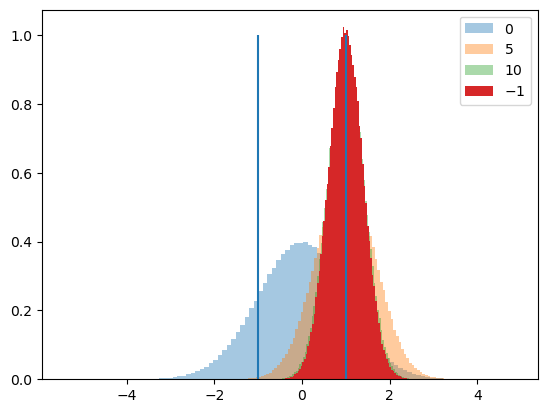

In [56]:
idx=0
for t in np.concatenate([np.arange(0, PKLs[idx]['res'][0].shape[1], 5), [-1]]):
    if t == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${-1}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=0.4, density=True, label=rf"${t}$")
plt.legend()
plt.vlines(x=1, ymin=0, ymax=1)
plt.vlines(x=-1, ymin=0, ymax=1)

In [95]:
vals

array([[[0.00000000e+00, 8.47040428e-06, 1.00647786e-03, ...,
         1.75890736e-02, 1.49311768e-02, 1.29426206e-02],
        [0.00000000e+00, 8.58307249e-06, 9.70229739e-04, ...,
         1.78633090e-02, 1.51504111e-02, 1.31219029e-02],
        [0.00000000e+00, 9.70581004e-06, 9.45718901e-04, ...,
         1.80856567e-02, 1.53280580e-02, 1.32669602e-02],
        ...,
        [3.90106905e-03, 1.29889771e-02, 8.55660737e-02, ...,
         1.15858270e-02, 1.01398341e-02, 9.00931098e-03],
        [1.20881228e-02, 3.35777737e-02, 1.38199955e-01, ...,
         1.09614842e-02, 9.63406358e-03, 8.59044213e-03],
        [4.08611745e-02, 5.56640252e-02, 1.16996147e-01, ...,
         1.03417216e-02, 9.13012028e-03, 8.17187317e-03]],

       [[0.00000000e+00, 2.38753455e-06, 8.98354992e-05, ...,
         1.09752643e+00, 1.08414662e+00, 1.07005239e+00],
        [0.00000000e+00, 1.57057639e-06, 8.38034903e-05, ...,
         1.11385548e+00, 1.09819078e+00, 1.08217943e+00],
        [0.00000000e+00, 

0.14148436


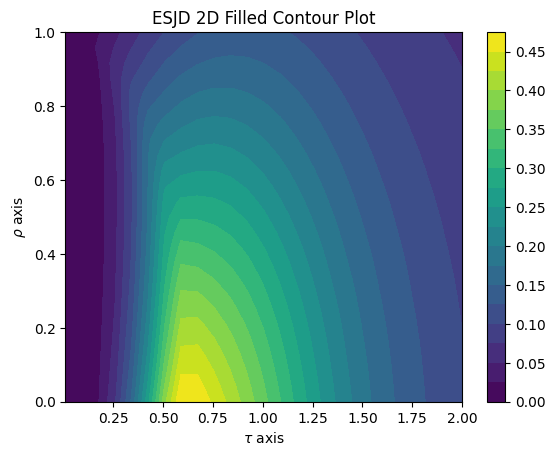

0.28406495


<Figure size 640x480 with 0 Axes>

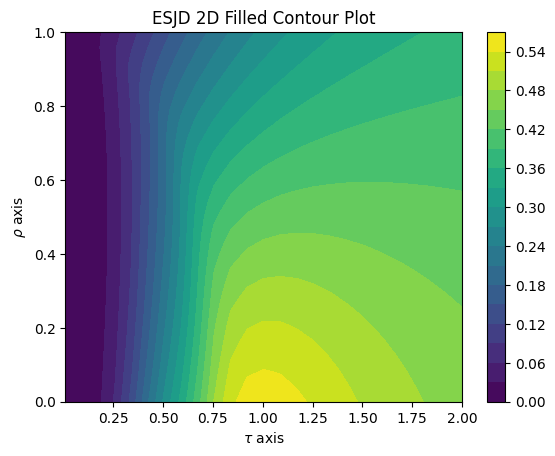

0.44848824


<Figure size 640x480 with 0 Axes>

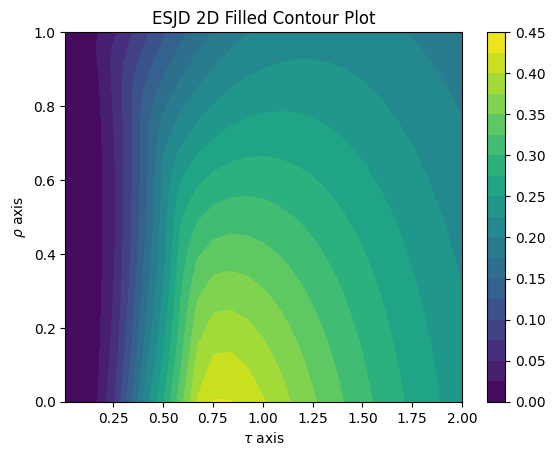

0.69539964


<Figure size 640x480 with 0 Axes>

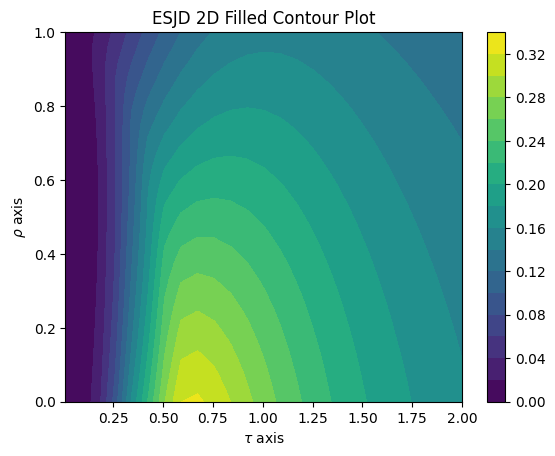

1.0


<Figure size 640x480 with 0 Axes>

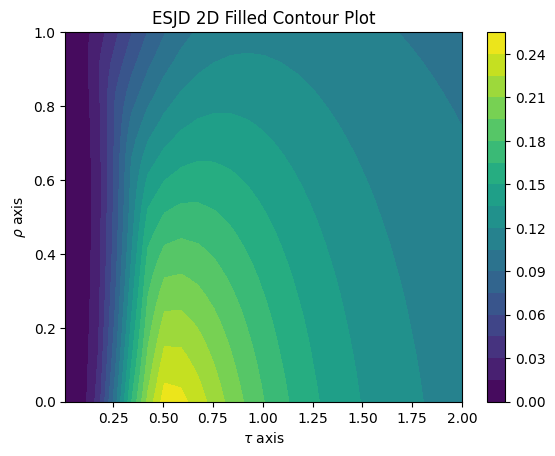

1.0


<Figure size 640x480 with 0 Axes>

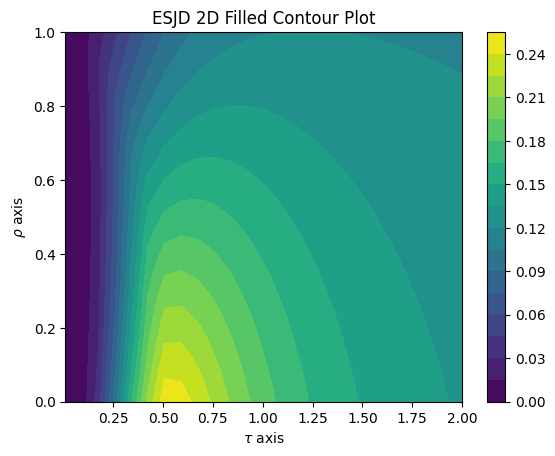

1.0


<Figure size 640x480 with 0 Axes>

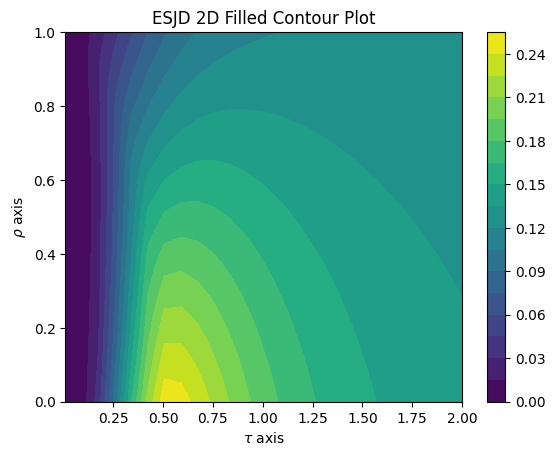

1.0


<Figure size 640x480 with 0 Axes>

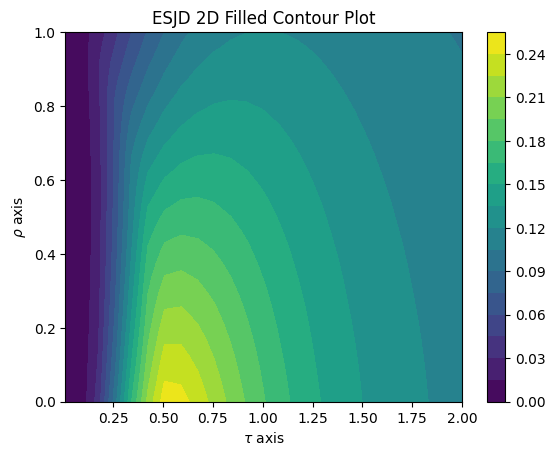

1.0


<Figure size 640x480 with 0 Axes>

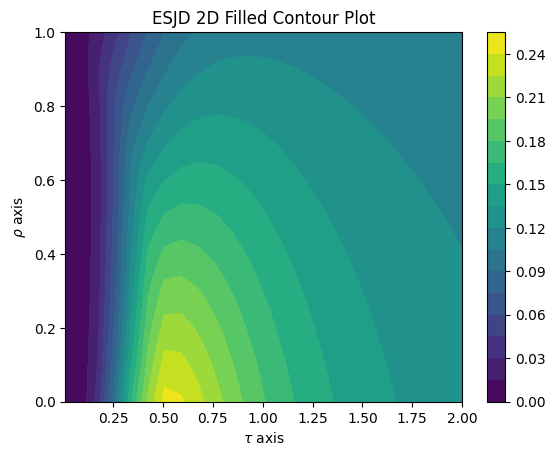

1.0


<Figure size 640x480 with 0 Axes>

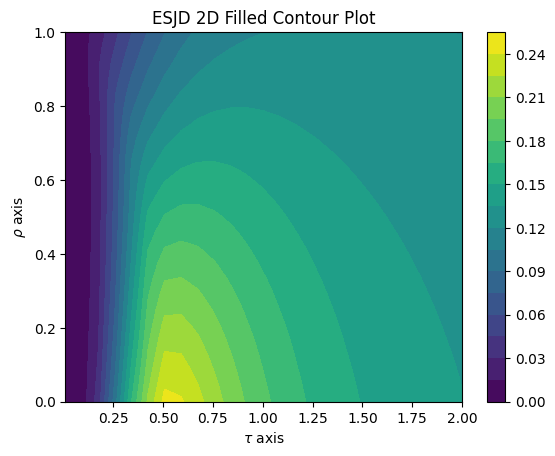

1.0


<Figure size 640x480 with 0 Axes>

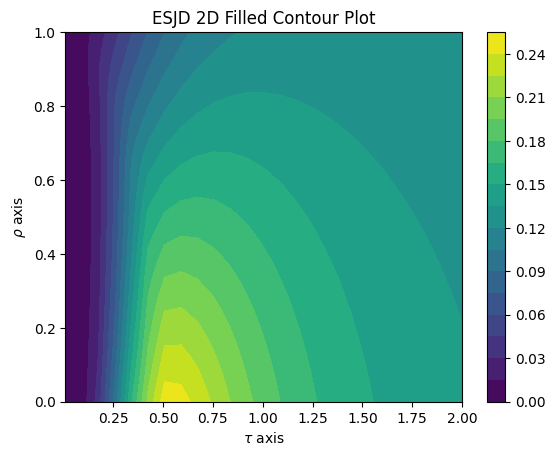

<Figure size 640x480 with 0 Axes>

In [9]:
rho_grid = jnp.linspace(0, 1, 25)
tau_grid = jnp.linspace(0.01, 2, 25)

idx = idx_proposal["build_build_uncoupled_autoregressive_gaussian_proposal"][0]
t = PKLs[idx]['res'][5].shape[1]
vals = np.array([PKLs[idx]['res'][5].mean(axis=0).reshape((t, rho_grid.shape[-1], tau_grid.shape[-1])) for idx in idx_proposal["build_build_uncoupled_autoregressive_gaussian_proposal"]]).mean(axis=0)
for t in np.arange(0, vals.shape[0], 1):
    print(PKLs[idx]['res'][6][:,t].mean())
    arr = vals[t]
    plot_contour2D(tau_grid, rho_grid,arr)
    plt.clf()

ValueError: 'x' and 'y' must have the same size

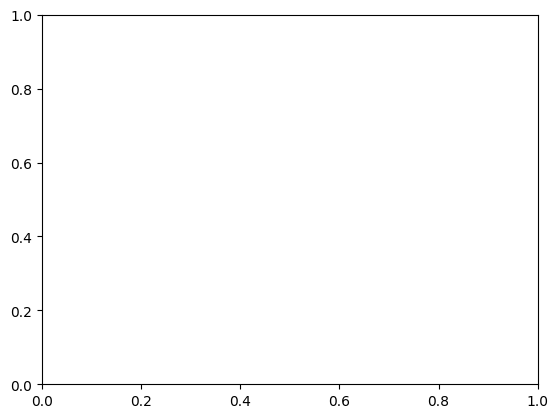

In [10]:
import jax
import jax.numpy as jnp
optimal_parameters = jnp.array([PKLs[idx]['res'][3] for idx in idx_proposal['build_build_uncoupled_autoregressive_gaussian_proposal']])
optimal_parameters = optimal_parameters.reshape((-1, *optimal_parameters.shape[2:]))
optimal_parameters = jnp.swapaxes(jnp.swapaxes(optimal_parameters, axis1=0, axis2=1), 1, -1)
optimal_parameters_std = jax.vmap(lambda x: jnp.diag(x))(jax.vmap(lambda x: jnp.cov(x, rowvar=True))(optimal_parameters))**0.5
param_idx = 0
plt.errorbar(x=np.arange(1, 16), y=optimal_parameters.mean(axis=-1)[:,param_idx], yerr=optimal_parameters_std[:,param_idx], label=r"$\rho$")
param_idx = 1
plt.errorbar(x=np.arange(1, 16), y=optimal_parameters.mean(axis=-1)[:,param_idx], yerr=optimal_parameters_std[:,param_idx], label=r"$\tau$")
mean_temperatures = jnp.array([PKLs[idx]['res'][6].mean(axis=0) for idx in idx_proposal['build_build_uncoupled_autoregressive_gaussian_proposal']]).mean(axis=0)
#plt.plot(np.diff(mean_temperatures))
plt.xlabel(r"Iteration $t$")
plt.legend()


In [132]:
mean_temperatures = {proposal: jnp.array([PKLs[idx]['res'][6].mean(axis=0) for idx in idx_proposal[proposal]]).mean(axis=0)
                     for proposal in idx_proposal}


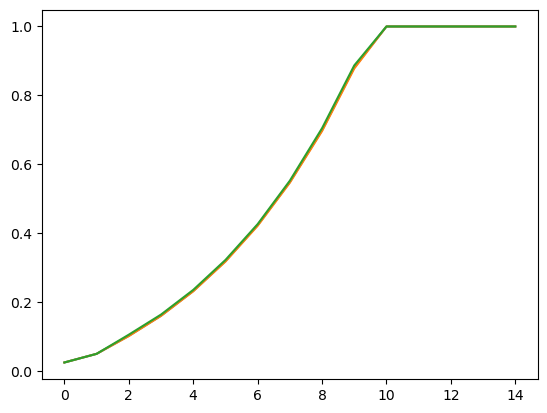

In [134]:
for proposal in idx_proposal:
    plt.plot(mean_temperatures[proposal])

In [130]:
x, y = np.meshgrid(rho_grid, tau_grid)

{'build_build_autoregressive_gaussian_proposal': Array([0.02546875, 0.05053955, 0.10271435, 0.16121179, 0.23272341,
        0.31945682, 0.42372558, 0.54872745, 0.69900215, 0.8813196 ,
        1.        , 1.        , 1.        , 1.        , 1.        ],      dtype=float32),
 'build_build_gaussian_rw_proposal': Array([0.02546875, 0.05053955, 0.10204462, 0.16053523, 0.23187006,
        0.31802273, 0.4217549 , 0.546863  , 0.6966092 , 0.8780374 ,
        1.        , 1.        , 1.        , 1.        , 1.        ],      dtype=float32),
 'build_build_uncoupled_autoregressive_gaussian_proposal': Array([0.02546875, 0.05053955, 0.10611805, 0.16442075, 0.23595157,
        0.3227102 , 0.42667678, 0.5526811 , 0.7048291 , 0.88702655,
        1.        , 1.        , 1.        , 1.        , 1.        ],      dtype=float32)}

In [26]:
rho_grid = jnp.linspace(0, 0.99, 25)
tau_grid = jnp.linspace(0.1, 1, 25)
params_grid = jnp.array([[x, y] for x in rho_grid for y in tau_grid])

In [126]:
idx_proposal

{'build_build_autoregressive_gaussian_proposal': [0,
  1,
  2,
  8,
  9,
  10,
  11,
  13,
  14,
  20,
  22,
  24,
  27,
  28,
  31,
  33,
  39,
  43,
  50,
  54,
  56,
  59,
  67,
  68,
  75,
  77,
  79,
  81,
  82,
  83,
  87,
  88,
  90,
  99,
  100,
  105,
  110,
  111,
  113,
  116,
  117,
  119,
  121,
  122,
  124,
  131,
  138,
  139,
  140,
  147,
  148,
  149,
  150,
  151,
  152,
  154,
  158,
  159,
  160,
  162,
  165,
  166,
  173,
  180,
  182,
  183,
  195,
  197,
  201,
  206,
  207,
  208,
  211,
  212,
  213,
  216,
  222,
  228,
  229,
  230,
  234,
  235,
  245,
  246,
  249,
  259,
  261,
  264,
  266,
  269,
  272,
  273,
  274,
  278,
  279,
  288,
  290,
  291,
  294,
  297],
 'build_build_gaussian_rw_proposal': [3,
  5,
  6,
  7,
  12,
  17,
  18,
  23,
  25,
  26,
  35,
  36,
  37,
  38,
  40,
  44,
  46,
  47,
  53,
  55,
  57,
  58,
  60,
  63,
  64,
  65,
  66,
  69,
  70,
  72,
  76,
  80,
  84,
  85,
  91,
  92,
  94,
  95,
  97,
  103,
  104,
  107,
  1

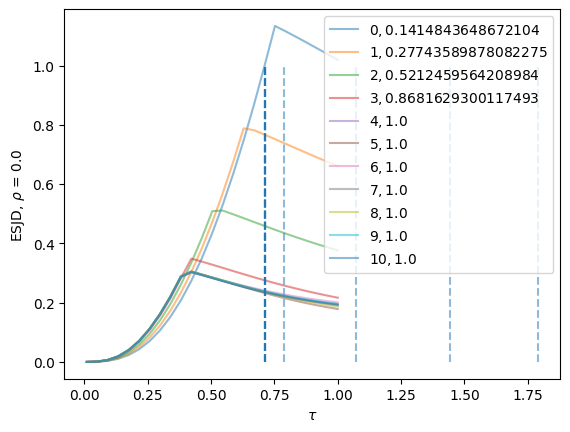

<Figure size 640x480 with 0 Axes>

In [35]:
def slice_esjd(idx=0, slic=-1, axis=0):
    grid = tau_grid if axis==1 else rho_grid
    opposite_grid = tau_grid if axis==0 else rho_grid
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    for t in np.arange(0, vals.shape[0], 1):
        my_slice = vals[t, :, slic] if axis==0 else vals[t, slic, :]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
        if axis==1:
            plt.vlines(x=2.38/np.sqrt(dim) * (lmbd*sigmasq**(-1)+1)**(-1), ymin=0, ymax=1,  linestyle="--", alpha=0.5)
    plt.legend()
    xlabel = r"$\rho$" if axis==0 else r"$\tau$"
    oppositexlabel = r"$\tau$" if axis==0 else r"$\rho$"
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD, "+oppositexlabel+" = "+str(opposite_grid[slic]))
    plt.show()
    plt.clf()

slice_esjd(0, 0, 1)

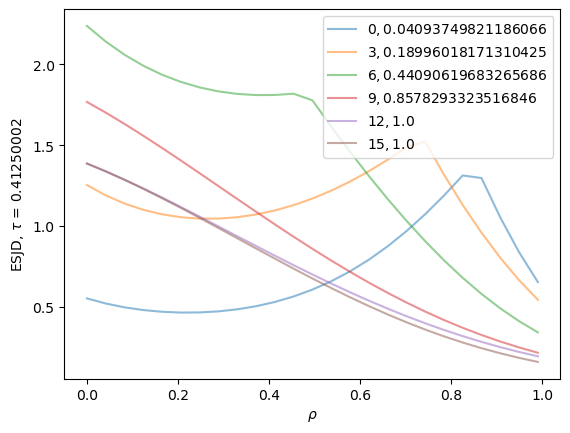

<Figure size 640x480 with 0 Axes>

In [28]:
slice_esjd(0, 10, 1)

(25, 16)


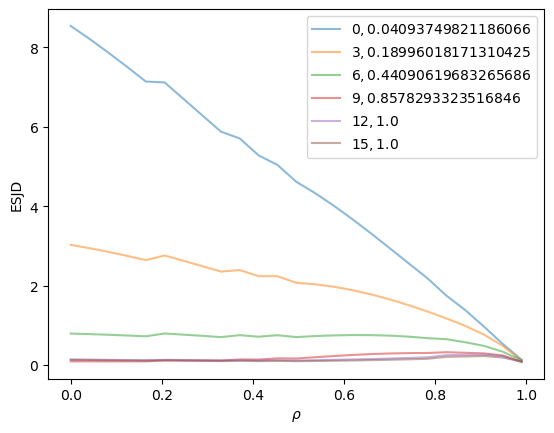

<Figure size 640x480 with 0 Axes>

In [54]:
def esjd_ar(idx, rho):
    tau = np.sqrt(1-rho**2)
    idx_tau  = np.argmin(np.abs(tau_grid - tau))
    idx_rho = np.argmin(np.abs(rho_grid - rho))
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    return vals[:, idx_rho, idx_tau]
def plot_esjd_ar(idx):
    grid = rho_grid
    esjd_along_the_circle = np.array([esjd_ar(idx, rho) for rho in rho_grid])
    print(esjd_along_the_circle.shape)
    for t in np.arange(0, vals.shape[0], 3):
        my_slice = esjd_along_the_circle[:,t]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
    plt.legend()
    xlabel = r"$\rho$"
    oppositexlabel = r"$\tau=\sqrt(1-\rho^2)$" 
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD")
    plt.show()
    plt.clf()
plot_esjd_ar(0)

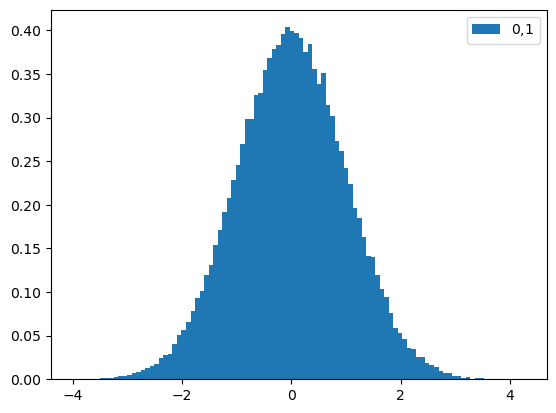

<Figure size 640x480 with 0 Axes>

In [8]:
def get_hist(idx, dim, t):
    if dim == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,..., dim].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$,${dim+1}$")
    plt.legend()
    plt.show()
    plt.clf()
get_hist(2, 0, 0)

In [61]:
PKLs[idx]['res'][6]

Array([[0.05350586, 0.10740402, 0.20531887, 0.3440556 , 0.530681  ,
        0.7685463 , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        ]], dtype=float32)